# Reproducing Plots from the Thesis
This notebook provides functionality for reproducing plots showing class-wise scores that are included in the thesis based on the evaluated model checkpoints. If you want to verify these results first, **evaluate_checkpoints.py** provides functionality for generating results in the expected format.

Some plots are not explicitly generated, as that would take a lot of redundant code. For example, the thesis shows plots over tail classes. To replicate this, some minor changes in code are necessary, e.g., changing indices to only consider the lower half of classes.

In [15]:
# Important: Always run this cell first! Otherwise the notebook will not see the required packages
from pathlib import Path
import os

current = Path.cwd().resolve()

for directory in [current, *current.parents]:
    if (directory / "models").is_dir():
        PROJECT_ROOT = directory
        break
else:
    raise FileNotFoundError(f"Could not locate the project root starting from {current}")

os.chdir(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: /home/tkarges/thesis-project


In [3]:
import torch
from tqdm.auto import tqdm
from types import SimpleNamespace
from datasets.metadata import get_dataset_info, get_label_mapping
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

%load_ext autoreload
%autoreload 2

def smooth_curve(y, window=15):
    y = np.asarray(y)

    if window < 2:
        return y

    pad_left = window // 2
    pad_right = window - 1 - pad_left

    y_padded = np.pad(y, (pad_left, pad_right), mode="edge")
    kernel = np.ones(window) / window

    return np.convolve(y_padded, kernel, mode="valid")

/work/tkarges/miniconda3/envs/thesis-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Evaluation Results: Chapter 3 (Fairness Analysis)
These are all of the relevant evaluation results generated for the analysis part of the thesis. The subsequent cells can be used to reproduce the same figures that are included in this chapter in the thesis document.
If you keep the exact repository structure from Git, these paths are correct. If you changed file locations, the paths need to be changed accordingly.

In [39]:
def pick_results(dataset, mode, model):
    if model == "deeplabv3":
        if dataset == "cityscapes":
            if mode == "segpgd3res":
                return {
                    "Clean": "analysis/results/cityscapes/deeplabv3/segpgd3res_cs_deeplabv3_pretrained_clean.pt",
                    "DDC-AT": "analysis/results/cityscapes/deeplabv3/segpgd3res_cs_deeplabv3_pretrained_ddcat.pt",
                    "SegPGD-AT": "analysis/results/cityscapes/deeplabv3/segpgd3res_cs_deeplabv3_segpgdat.pt",
                    "SegPGD-AT-100": "analysis/results/cityscapes/deeplabv3/segpgd3res_cs_deeplabv3_segpgdat100.pt"
                }
            elif mode == "cleanres":
                return {
                    "Clean": "analysis/results/cityscapes/deeplabv3/cleanres_cs_deeplabv3_pretrained_clean.pt",
                    "DDC-AT": "analysis/results/cityscapes/deeplabv3/cleanres_cs_deeplabv3_pretrained_ddcat.pt",
                    "SegPGD-AT": "analysis/results/cityscapes/deeplabv3/cleanres_cs_deeplabv3_segpgdat.pt",
                    "SegPGD-AT-100": "analysis/results/cityscapes/deeplabv3/cleanres_cs_deeplabv3_segpgdat100.pt"
                }
        elif dataset == "voc2012":
            if mode == "segpgd3res":
                return {
                    "Clean": "analysis/results/voc2012/deeplabv3/segpgd3res_voc_deeplabv3_pretrained_clean.pt",
                    "DDC-AT": "analysis/results/voc2012/deeplabv3/segpgd3res_voc_deeplabv3_pretrained_ddcat.pt",
                    "SegPGD-AT": "analysis/results/voc2012/deeplabv3/segpgd3res_voc_deeplabv3_segpgdat.pt",
                    "SegPGD-AT-100": "analysis/results/voc2012/deeplabv3/segpgd3res_voc_deeplabv3_segpgdat100.pt"
                }
            elif mode == "cleanres":
                return {
                    "Clean": "analysis/results/voc2012/deeplabv3/cleanres_voc_deeplabv3_pretrained_clean.pt",
                    "DDC-AT": "analysis/results/voc2012/deeplabv3/cleanres_voc_deeplabv3_pretrained_ddcat.pt",
                    "SegPGD-AT": "analysis/results/voc2012/deeplabv3/cleanres_voc_deeplabv3_segpgdat.pt",
                    "SegPGD-AT-100": "analysis/results/voc2012/deeplabv3/cleanres_voc_deeplabv3_segpgdat100.pt"
                }
    elif model == "pspnet":
        if dataset == "cityscapes":
            if mode == "segpgd3res":
                return {
                    "Clean": "analysis/results/cityscapes/pspnet/segpgd3res_cs_pspnet_pretrained_clean.pt",
                    "DDC-AT": "analysis/results/cityscapes/pspnet/segpgd3res_cs_pspnet_pretrained_ddcat.pt",
                    "SegPGD-AT": "analysis/results/cityscapes/pspnet/segpgd3res_cs_pspnet_segpgdat.pt",
                    "SegPGD-AT-100": "analysis/results/cityscapes/pspnet/segpgd3res_cs_pspnet_segpgdat100.pt"
                }
            elif mode == "cleanres":
                return {
                    "Clean": "analysis/results/cityscapes/pspnet/cleanres_cs_pspnet_pretrained_clean.pt",
                    "DDC-AT": "analysis/results/cityscapes/pspnet/cleanres_cs_pspnet_pretrained_ddcat.pt",
                    "SegPGD-AT": "analysis/results/cityscapes/pspnet/cleanres_cs_pspnet_segpgdat.pt",
                    "SegPGD-AT-100": "analysis/results/cityscapes/pspnet/cleanres_cs_pspnet_segpgdat100.pt"
                }
        elif dataset == "voc2012":
            if mode == "segpgd3res":
                return {
                    "Clean": "analysis/results/voc2012/pspnet/segpgd3res_voc_pspnet_pretrained_clean.pt",
                    "DDC-AT": "analysis/results/voc2012/pspnet/segpgd3res_voc_pspnet_pretrained_ddcat.pt",
                    "SegPGD-AT": "analysis/results/voc2012/pspnet/segpgd3res_voc_pspnet_segpgdat.pt",
                    "SegPGD-AT-100": "analysis/results/voc2012/pspnet/segpgd3res_voc_pspnet_segpgdat100.pt"
                }
            elif mode == "cleanres":
                return {
                    "Clean": "analysis/results/voc2012/pspnet/cleanres_voc_pspnet_pretrained_clean.pt",
                    "DDC-AT": "analysis/results/voc2012/pspnet/cleanres_voc_pspnet_pretrained_ddcat.pt",
                    "SegPGD-AT": "analysis/results/voc2012/pspnet/cleanres_voc_pspnet_segpgdat.pt",
                    "SegPGD-AT-100": "analysis/results/voc2012/pspnet/cleanres_voc_pspnet_segpgdat100.pt"
                }
    return {}

### Score comparisons (Fig. 3.2, 3.6)

In [40]:
def class_score_plot(dataset, clean=True, model="deeplabv3"):
    if clean:
        mode = "cleanres"
    else:
        mode = "segpgd3res"
    model_results = pick_results(dataset, mode, model)
    #num_classes, ignore_index, dataset_root, easy_classes, hard_classes = get_dataset_info(dataset)
    label_mapping = get_label_mapping(dataset)
    ref_scores = torch.load(model_results['Clean'], map_location='cpu', weights_only=True)["per_class_score"]
    
    sort_idx = ref_scores.sort(descending=True).indices
    sort_idx_list = [i.item() for i in sort_idx]
    xlabels = [label_mapping[i] for i in sort_idx_list]
    x = list(range(len(xlabels)))
    
    fig, ax = plt.subplots(figsize=(8,6))
    
    for model_name, result_path in model_results.items():
        result = torch.load(result_path, map_location='cpu', weights_only=True)
        scores = result["per_class_score"]
        scores_sorted = scores[sort_idx]
    
        ax.plot(
            x,
            smooth_curve(scores_sorted.detach().cpu().numpy(), window=5)*100,
            label=model_name,
            linewidth=2,
        )
        
        ax.plot(
            x,
            scores_sorted.detach().cpu().numpy()*100,
            linewidth=2,
            alpha=0.25
        )
    
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Sorted class index")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    ax.set_ylabel("IoU")
    ax.set_ylim(0, 100)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

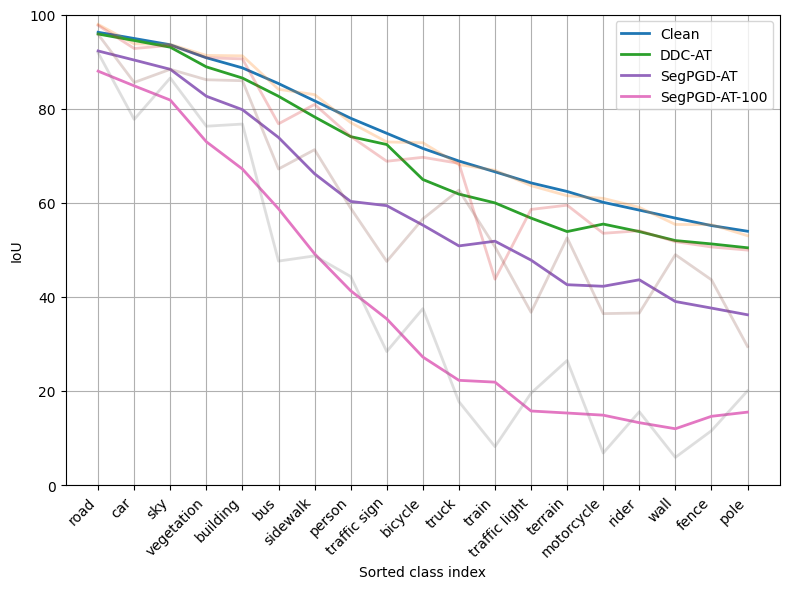

In [41]:
class_score_plot("cityscapes", clean=True)
#class_score_plot("voc2012", clean=True)
#class_score_plot("cityscapes", clean=False)
#class_score_plot("voc2012", clean=False)

### Model Prodication Bias (Fig. 3.3, 3.7)

In [42]:
def prediction_bias_plot(dataset, subset="all", clean=True, model="deeplabv3"):
    if clean:
        mode = "cleanres"
    else:
        mode = "segpgd3res"
    model_results = pick_results(dataset, mode, model)

    if dataset == "cityscapes":
        class_dist = torch.load('datasets/cityscapes/class_dist_val.pt', map_location='cpu', weights_only=True)
    else:
        class_dist = torch.load('datasets/voc2012/class_dist_val.pt', map_location='cpu', weights_only=True)
        
    sort_idx = class_dist['class_dist'].sort(descending=True)[1]
    sort_idx_list = [i.item() for i in sort_idx]

    label_mapping = get_label_mapping(dataset)
    xlabels = [label_mapping[i] for i in sort_idx_list]
    x = list(range(len(xlabels)))

    if subset == "all":
        bias_key = "gn"
        freq_key = "cf"
    elif subset == "easy":
        bias_key = "gn_easy"
        freq_key = "cf_easy"
    elif subset == "hard":
        bias_key = "gn_hard"
        freq_key = "cf_hard"
    
    fig, ax = plt.subplots(figsize=(8,6))
    for model_name, result_path in model_results.items():
        result = torch.load(result_path, map_location='cpu', weights_only=True)
        
        eps = 1e-7
        gn = result[bias_key]
        cf = result[freq_key]

        scores = gn / gn.sum()
        scores_sorted = scores[sort_idx]
        ax.plot(
            x,
            scores_sorted.detach().cpu().numpy(),
            linewidth=2,
            label=model_name
        )
    
    #ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Classes sorted by Frequency")
    ax.set_ylabel("Normalized Model Prediction Bias")
    ax.set_ylim(0, 0.35)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    plt.legend()
    plt.grid()
    plt.tight_layout
    #plt.savefig('analysis/figures/mpb/mpb_cityscapes_adv_hard.pdf')
    plt.show()

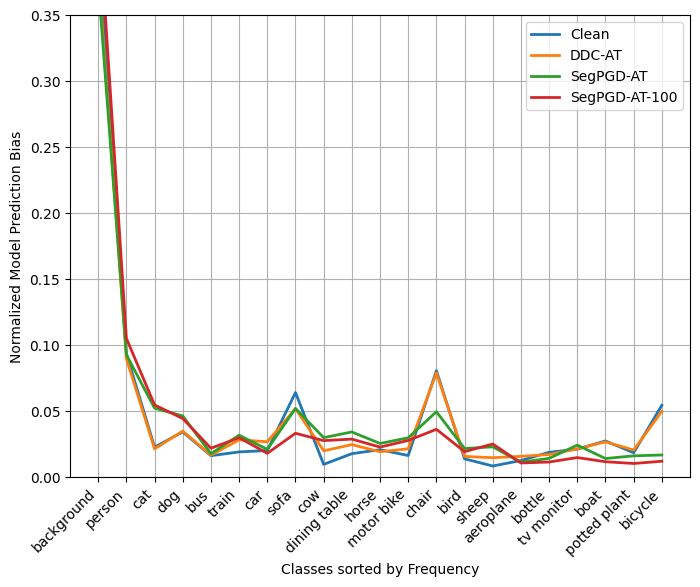

In [43]:
# Dataset can either be cityscapes or voc2012
prediction_bias_plot(dataset="voc2012", subset="all", model="deeplabv3", clean=True)

### Frequency-Normalized Prediction Bias (Fig. 3.4, 3.8)

In [44]:
def freq_norm_bias_plot(dataset, clean=True, model="deeplabv3", pred_mass=False):
    if clean:
        mode = "cleanres"
    else:
        mode = "segpgd3res"
    model_results = pick_results(dataset, mode, model)

    if dataset == "cityscapes":
        class_dist = torch.load('datasets/cityscapes/class_dist_val.pt', map_location='cpu', weights_only=True)
    else:
        class_dist = torch.load('datasets/voc2012/class_dist_val.pt', map_location='cpu', weights_only=True)
        
    sort_idx = class_dist['class_dist'].sort(descending=True)[1]
    sort_idx_list = [i.item() for i in sort_idx]

    label_mapping = get_label_mapping(dataset)
    xlabels = [label_mapping[i] for i in sort_idx_list]
    x = list(range(len(xlabels)))
    
    fig, ax = plt.subplots(figsize=(8,6))
    for model_name, result_path in model_results.items():
        result = torch.load(result_path, map_location='cpu', weights_only=True)
        
        eps = 1e-7

        if pred_mass:
            gn = result["gp"]
        else:
            gn = result["gn"]
        cf = result["cf"]
        scores = gn / gn.sum()
        pixel_freq = cf / cf.sum()
        scores = scores / pixel_freq
        scores_sorted = scores[sort_idx]
        ax.plot(
            x,
            scores_sorted.detach().cpu().numpy(),
            linewidth=2,
            label=model_name
        )
    
    #ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Classes sorted by Frequency")
    ax.set_ylabel("Normalized Model Prediction Bias" if not pred_mass else "Frequency-Normalized Correct Prediction Mass")
    ylim_upper = 10 if not pred_mass else 1.5
    ax.set_ylim(0, ylim_upper)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    plt.legend()
    plt.grid()
    plt.tight_layout
    plt.show()

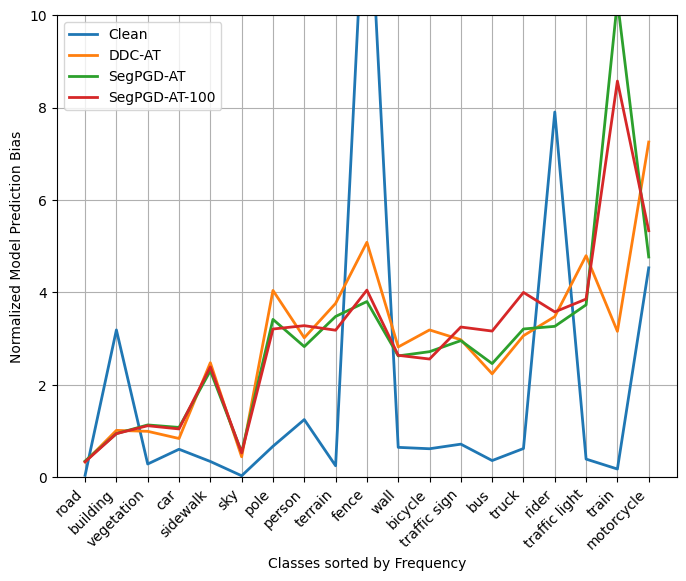

In [45]:
freq_norm_bias_plot(dataset="cityscapes", model="deeplabv3", clean=False)

### Frequency-Normalized Correct Prediction Mass (Fig. 3.5, 3.9)

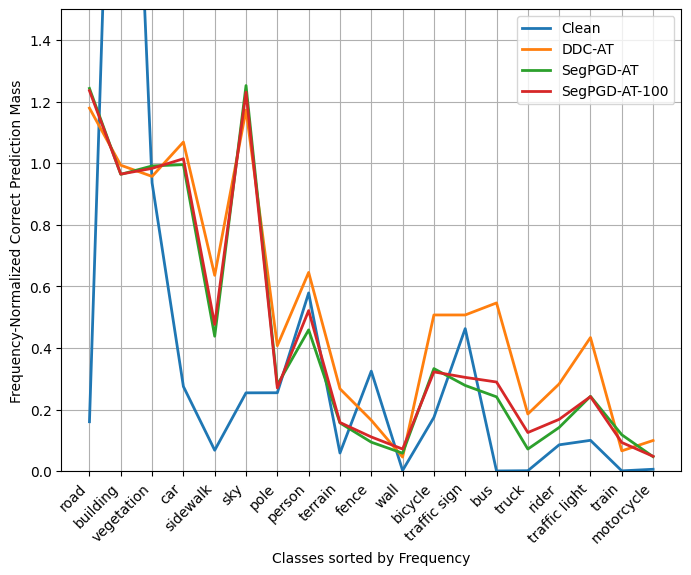

In [46]:
freq_norm_bias_plot(dataset="cityscapes", model="deeplabv3", clean=False, pred_mass=True)

### Evaluations Results of DAFA

In [16]:
def pick_results_dafa(clean=False):
    if clean:
        return {
            "DAFA-CE": "analysis/results/dafa/cleanres_cs_deeplabv3_dafa_ce.pt",
            "DAFA-TRADES": "analysis/results/dafa/cleanres_cs_deeplabv3_dafa_trades.pt",
            "SegPGD-AT": "analysis/results/cityscapes/deeplabv3/cleanres_cs_deeplabv3_segpgdat.pt"
        }
    else:
        return {
            "DAFA-CE": "analysis/results/dafa/segpgd3res_cs_deeplabv3_dafa_ce.pt",
            "DAFA-TRADES": "analysis/results/dafa/segpgd3res_cs_deeplabv3_dafa_trades.pt",
            "SegPGD-AT": "analysis/results/cityscapes/deeplabv3/segpgd3res_cs_deeplabv3_segpgdat.pt"
        }

In [17]:
def class_score_plot_dafa(clean=False, metric="iou"):
    model_results = pick_results_dafa(clean=clean)
    label_mapping = get_label_mapping("cityscapes")
    ref_scores = torch.load(model_results['SegPGD-AT'], map_location='cpu', weights_only=True)["per_class_score"]
    
    sort_idx = ref_scores.sort(descending=True).indices
    sort_idx_list = [i.item() for i in sort_idx]
    xlabels = [label_mapping[i] for i in sort_idx_list]
    x = list(range(len(xlabels)))
    
    fig, ax = plt.subplots(figsize=(8,6))

    if metric == "iou":
        metric_key = "per_class_score"
    elif metric == "precision":
        metric_key = "pr_per_class"
    elif metric == "recall":
        metric_key = "rc_per_class"
    
    for model_name, result_path in model_results.items():
        result = torch.load(result_path, map_location='cpu', weights_only=True)
        scores = result[metric_key]
        scores_sorted = scores[sort_idx]
    
        ax.plot(
            x,
            smooth_curve(scores_sorted.detach().cpu().numpy(), window=5)*100,
            label=model_name,
            linewidth=2,
        )
        
        ax.plot(
            x,
            scores_sorted.detach().cpu().numpy()*100,
            linewidth=2,
            alpha=0.25
        )
    
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Sorted class index")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    ax.set_ylabel("IoU")
    ax.set_ylim(0, 100)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

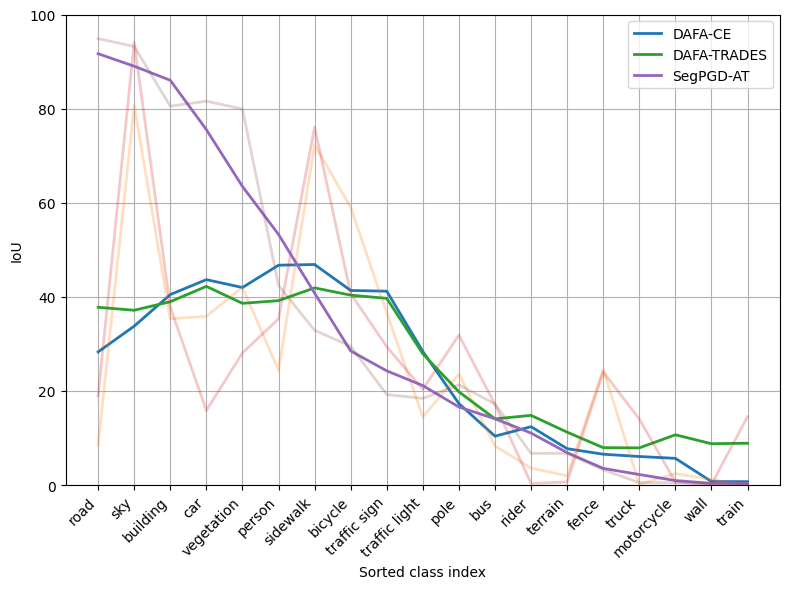

In [21]:
class_score_plot_dafa(clean=False, metric="recall")

### Evaluation Results for Reinforcement Learning

In [22]:
def pick_results_rl(clean=False):
    if clean:
        return {
            "SegPGD-AT": "analysis/results/cityscapes/deeplabv3/cleanres_cs_deeplabv3_segpgdat.pt",
            "RL-Adv-Only": "analysis/results/rl_final/cleanres_RL_adv_weight_noclean.pt",
            "RL-Both": "analysis/results/rl_final/cleanres_RL_both_weight.pt",
            "RL-Adv": "analysis/results/rl_final/cleanres_RL_adv_weight.pt",
            "RL-Clean": "analysis/results/rl_final/cleanres_RL_clean_weight.pt",
            "RL-FT": "analysis/results/rl_final/cleanres_RL_ft.pt"
        }
    else:
        return {
            "SegPGD-AT": "analysis/results/cityscapes/deeplabv3/segpgd3res_cs_deeplabv3_segpgdat.pt",
            "RL-Adv-Only": "analysis/results/rl_final/segpgd3res_RL_adv_weight_noclean.pt",
            "RL-Both": "analysis/results/rl_final/segpgd3res_RL_both_weight.pt",
            "RL-Adv": "analysis/results/rl_final/segpgd3res_RL_adv_weight.pt",
            "RL-Clean": "analysis/results/rl_final/segpgd3res_RL_clean_weight.pt",
            "RL-FT": "analysis/results/rl_final/segpgd3res_RL_ft.pt"
        }

In [25]:
def class_score_plot_rl(clean=False, metric="iou"):
    model_results = pick_results_rl(clean=clean)
    label_mapping = get_label_mapping("cityscapes")
    ref_scores = torch.load(model_results['SegPGD-AT'], map_location='cpu', weights_only=True)["per_class_score"]
    
    sort_idx = ref_scores.sort(descending=True).indices
    sort_idx_list = [i.item() for i in sort_idx]
    xlabels = [label_mapping[i] for i in sort_idx_list]
    x = list(range(len(xlabels)))
    
    fig, ax = plt.subplots(figsize=(8,6))

    if metric == "iou":
        metric_key = "per_class_score"
    elif metric == "precision":
        metric_key = "pr_per_class"
    elif metric == "recall":
        metric_key = "rc_per_class"
    
    for model_name, result_path in model_results.items():
        result = torch.load(result_path, map_location='cpu', weights_only=True)
        scores = result[metric_key]
        scores_sorted = scores[sort_idx]
    
        ax.plot(
            x,
            smooth_curve(scores_sorted.detach().cpu().numpy(), window=5)*100,
            label=model_name,
            linewidth=2,
        )
        
        ax.plot(
            x,
            scores_sorted.detach().cpu().numpy()*100,
            linewidth=2,
            alpha=0.25
        )
    
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Sorted class index")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    ax.set_ylabel("IoU")
    ax.set_ylim(0, 100)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

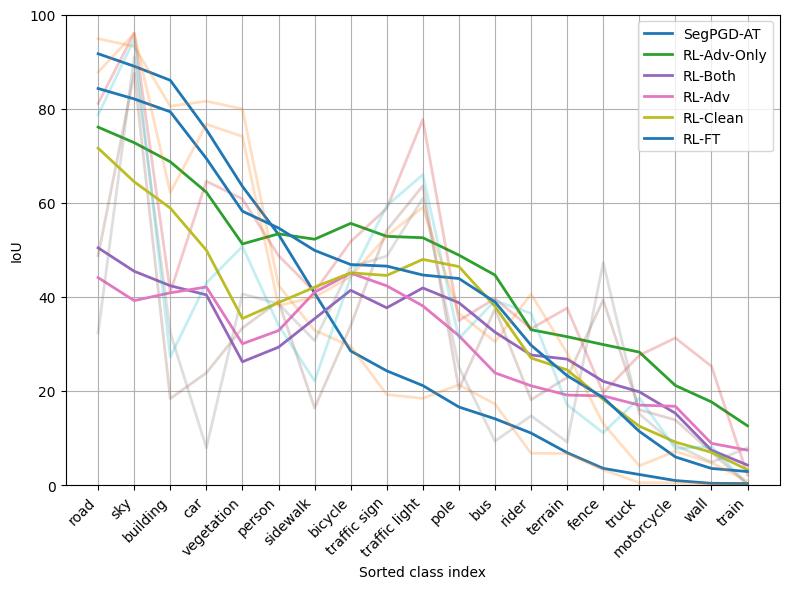

In [24]:
class_score_plot_rl(clean=False, metric="recall")